# Training Data
## Preprocess the Data

Create binary variable from Class

In [17]:
train <- read.csv('https://gedeck.github.io/DS-6030/projects/data/HaitiPixels.csv')

train$BlueTarp <- ifelse(train$Class == 'Blue Tarp','Blue Tarp', 'Non-Tarp' )

## Exploratory Data Analysis

Blue Tarp vs Non-Blue Tarp count in Data

In [18]:
table(train$BlueTarp)


Blue Tarp  Non-Tarp 
     2022     61219 

Visualization of the number of Blue Tarp vs Non-Blue Tarp

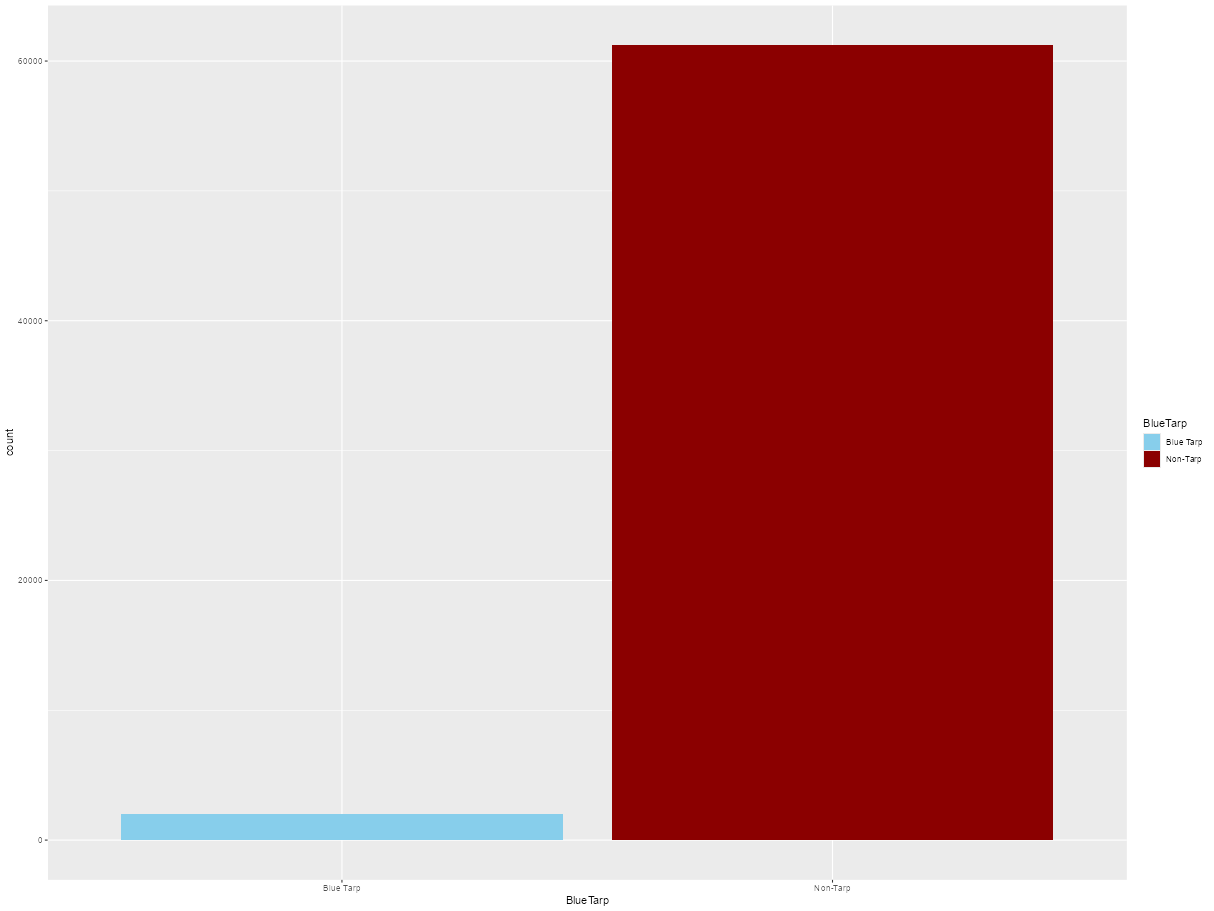

In [19]:
library(ggplot2)

train |>
  ggplot(aes(x = BlueTarp, fill = BlueTarp)) +
  geom_bar() +
  scale_fill_manual(values = c('Blue Tarp' = 'skyblue', 'Non-Tarp' = 'darkred'))

Boxplots for binary against colors

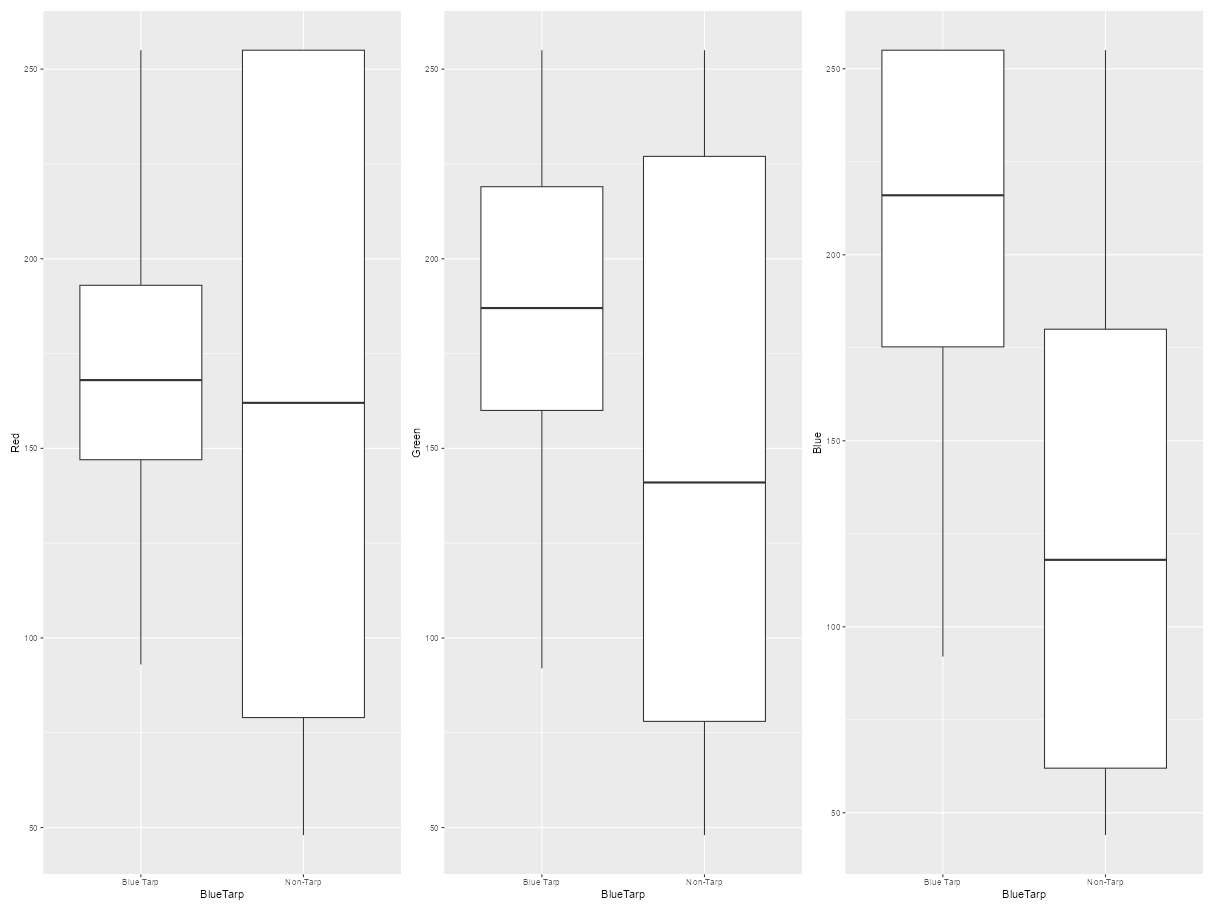

In [20]:
#| fig.width: 9
#| fig.height: 8
#| fig.align: center
#| out.width: 75%
library(patchwork)

b1 <- ggplot(train, aes(x = BlueTarp, y = Red)) +
  geom_boxplot()
b2 <- ggplot(train, aes(x = BlueTarp, y = Green)) +
  geom_boxplot()
b3 <- ggplot(train, aes(x = BlueTarp, y = Blue)) +
  geom_boxplot()
b1+b2+b3

Histograms of color variables

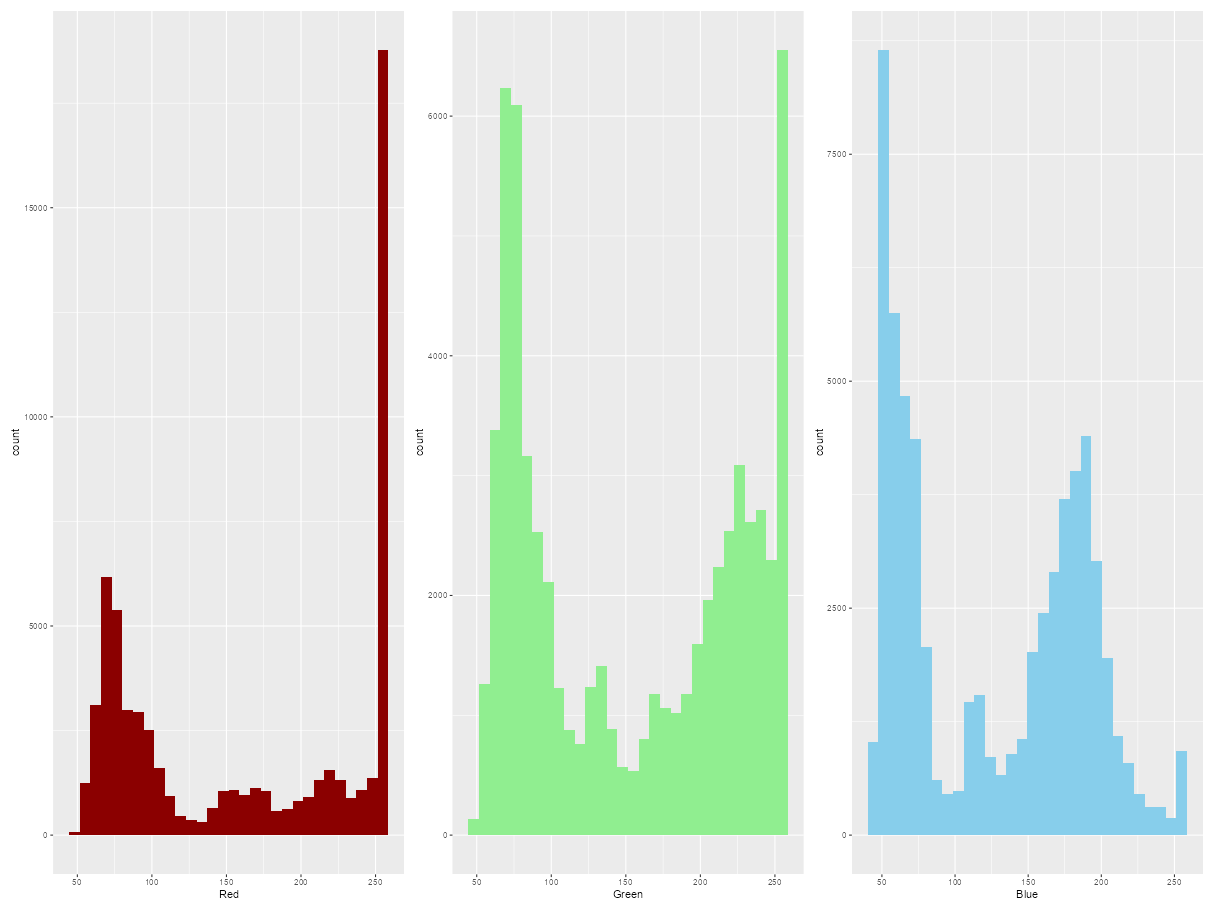

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.

In [21]:
#| fig.width: 7
#| fig.height: 3

g1 <-ggplot(train, aes(Red)) +
  geom_histogram(fill='darkred')
g2 <- ggplot(train, aes(Green)) +
  geom_histogram(fill='lightgreen')
g3 <- ggplot(train, aes(Blue)) +
  geom_histogram(fill='skyblue')
g1+g2+g3

# Holdout Data

In [22]:
library(tidyverse)
library(tidymodels)
library(patchwork)

## Hold-Out Data: Unzip the file

In [23]:
# Create folder if it doesn't exist
dir.create("HoldOut", showWarnings = FALSE)

# Download the zip file
download.file(
  "https://gedeck.github.io/DS-6030/projects/data/HoldOutData.zip",
  destfile = "HoldOutData.zip",
  mode = "wb"
)

# Unzip it
unzip("HoldOutData.zip", exdir = "HoldOut")

# Check files
list.files("HoldOut")

trying URL 'https://gedeck.github.io/DS-6030/projects/data/HoldOutData.zip'
Content type 'application/x-zip-compressed' length 25264676 bytes (24.1 MB)
downloaded 24.1 MB



 [1] "orthovnir057_ROI_NON_Blue_Tarps.txt" 
 [2] "orthovnir067_ROI_Blue_Tarps.txt"     
 [3] "orthovnir067_ROI_Blue_Tarps_data.txt"
 [4] "orthovnir067_ROI_NOT_Blue_Tarps.txt" 
 [5] "orthovnir069_ROI_Blue_Tarps.txt"     
 [6] "orthovnir069_ROI_NOT_Blue_Tarps.txt" 
 [7] "orthovnir071_makeshift_villiage1.jpg"
 [8] "orthovnir071_makeshift_villiage2.jpg"
 [9] "orthovnir078_makeshift_villiage1.jpg"
[10] "orthovnir078_ROI_Blue_Tarps.txt"     
[11] "orthovnir078_ROI_NON_Blue_Tarps.txt" 

## Parse single ENVI ROI file

In [24]:
parse_envi_roi <- function(filepath, label) {
  read_table(
    filepath,
    comment    = ";",
    col_names  = c("ID", "X", "Y", "Map_X", "Map_Y",
                   "Lat", "Lon", "Red", "Green", "Blue"),
    col_types  = cols(.default = col_double()),
    show_col_types = FALSE
  ) |>
    select(Red, Green, Blue) |>
    mutate(
      BlueTarp = factor(label, levels = c(0, 1),
                        labels = c("Non-Tarp", "Blue Tarp"))
    )
}

## Load all files and combine into one df

In [25]:
files <- tribble(
  ~path,                                      ~label,
  "HoldOut/orthovnir057_ROI_NON_Blue_Tarps.txt",       0,
  "HoldOut/orthovnir067_ROI_Blue_Tarps.txt",           1,
  "HoldOut/orthovnir067_ROI_NOT_Blue_Tarps.txt",       0,
  "HoldOut/orthovnir069_ROI_Blue_Tarps.txt",           1,
  "HoldOut/orthovnir069_ROI_NOT_Blue_Tarps.txt",       0,
  "HoldOut/orthovnir078_ROI_Blue_Tarps.txt",           1,
  "HoldOut/orthovnir078_ROI_NON_Blue_Tarps.txt",       0
)
 
holdout <- pmap_dfr(files, ~ parse_envi_roi(..1, ..2))
cat("Total rows:", scales::comma(nrow(holdout)), "\n\n")

Total rows: 2,004,177 



## Data quality checks

In [26]:
cat("Dimensions \n")
glimpse(holdout)
 
cat("\n Missing values \n")
print(colSums(is.na(holdout)))
 
cat("\n Value ranges (should be 0–255) \n")
holdout |>
  select(Red, Green, Blue) |>
  summary() |>
  print()
 
cat("\n Duplicate rows \n")
n_dupes <- sum(duplicated(holdout |> select(Red, Green, Blue, BlueTarp)))
cat("Duplicates:", scales::comma(n_dupes), "\n")
 
cat("\n Class distribution \n")
class_counts <- holdout |> count(BlueTarp)
print(class_counts)
 
imbalance_ratio <- class_counts$n[class_counts$BlueTarp == "Non-Tarp"] /
                   class_counts$n[class_counts$BlueTarp == "Blue Tarp"]
cat("Imbalance ratio:", round(imbalance_ratio, 0), ":1 (Non-Tarp : Blue Tarp)\n")

Dimensions 
Rows: 2,004,177
Columns: 4
$ Red      <dbl> 104, 101, 103, 107, 109, 103, 100, 98, 97, 99, 103, 104, 101,…
$ Green    <dbl> 89, 80, 87, 93, 99, 73, 79, 70, 73, 79, 84, 86, 83, 79, 77, 8…
$ Blue     <dbl> 63, 60, 69, 72, 68, 53, 56, 51, 56, 61, 63, 62, 61, 58, 56, 5…
$ BlueTarp <fct> Non-Tarp, Non-Tarp, Non-Tarp, Non-Tarp, Non-Tarp, Non-Tarp, N…

 Missing values 
     Red    Green     Blue BlueTarp 
       0        0        0        0 

 Value ranges (should be 0–255) 
      Red            Green            Blue       
 Min.   : 27.0   Min.   : 28.0   Min.   : 25.00  
 1st Qu.: 76.0   1st Qu.: 71.0   1st Qu.: 55.00  
 Median :107.0   Median : 91.0   Median : 66.00  
 Mean   :118.3   Mean   :105.4   Mean   : 82.36  
 3rd Qu.:139.0   3rd Qu.:117.0   3rd Qu.: 88.00  
 Max.   :255.0   Max.   :255.0   Max.   :255.00  

 Duplicate rows 
Duplicates: 1,649,784 

 Class distribution 
# A tibble: 2 × 2
  BlueTarp        n
  <fct>       <int>
1 Non-Tarp  1989697
2 Blue Tarp   14480
Imba

## Exploratory Data Analysis

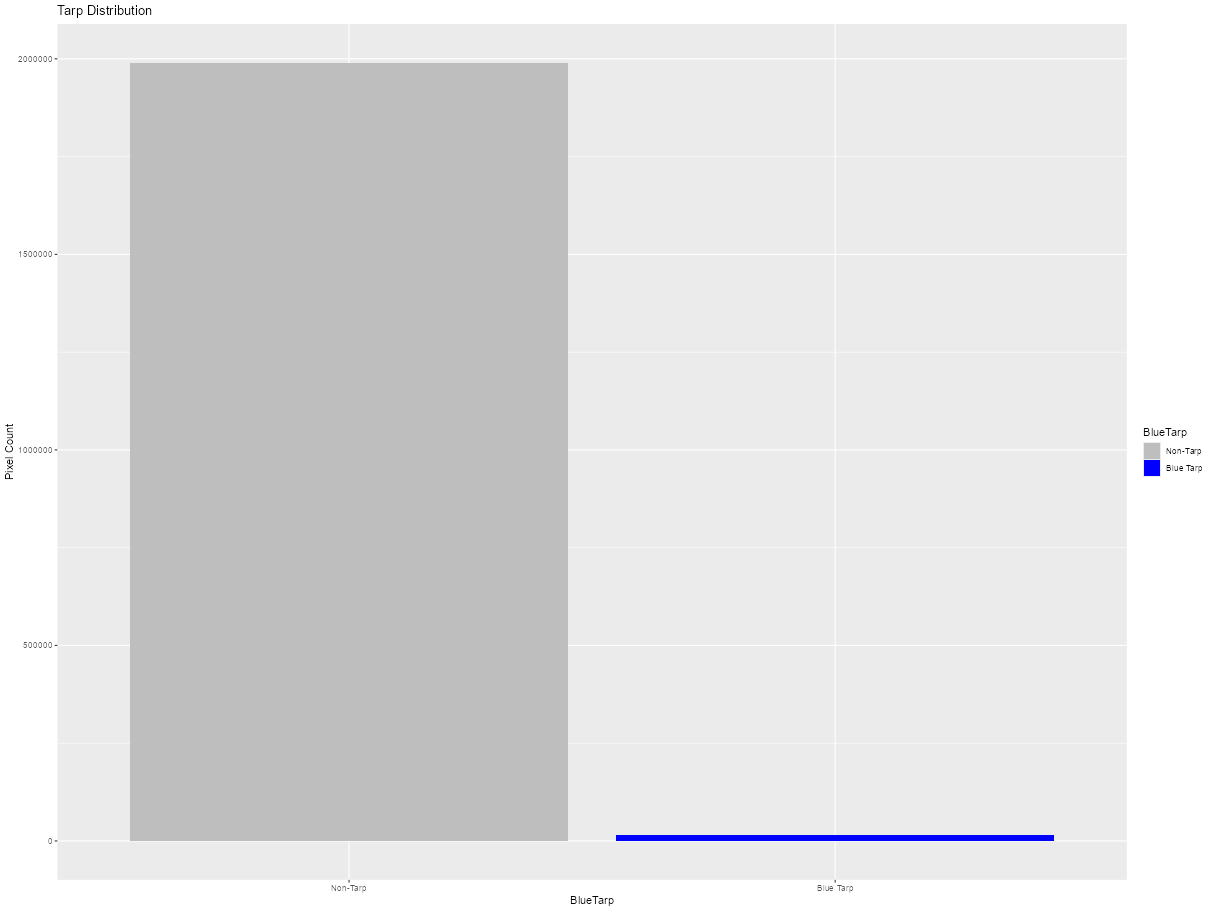

In [27]:
holdout |>
  ggplot(aes(x = BlueTarp, fill = BlueTarp)) +
  labs(title = "Tarp Distribution",
       y = "Pixel Count") +
  geom_bar() +
  scale_fill_manual(values = c("Non-Tarp" = "grey", "Blue Tarp" = "blue"))

Rows: 6,012,531
Columns: 3
$ BlueTarp  <fct> Non-Tarp, Non-Tarp, Non-Tarp, Non-Tarp, Non-Tarp, Non-Tarp, …
$ Channel   <fct> Red, Green, Blue, Red, Green, Blue, Red, Green, Blue, Red, G…
$ Intensity <dbl> 104, 89, 63, 101, 80, 60, 103, 87, 69, 107, 93, 72, 109, 99,…


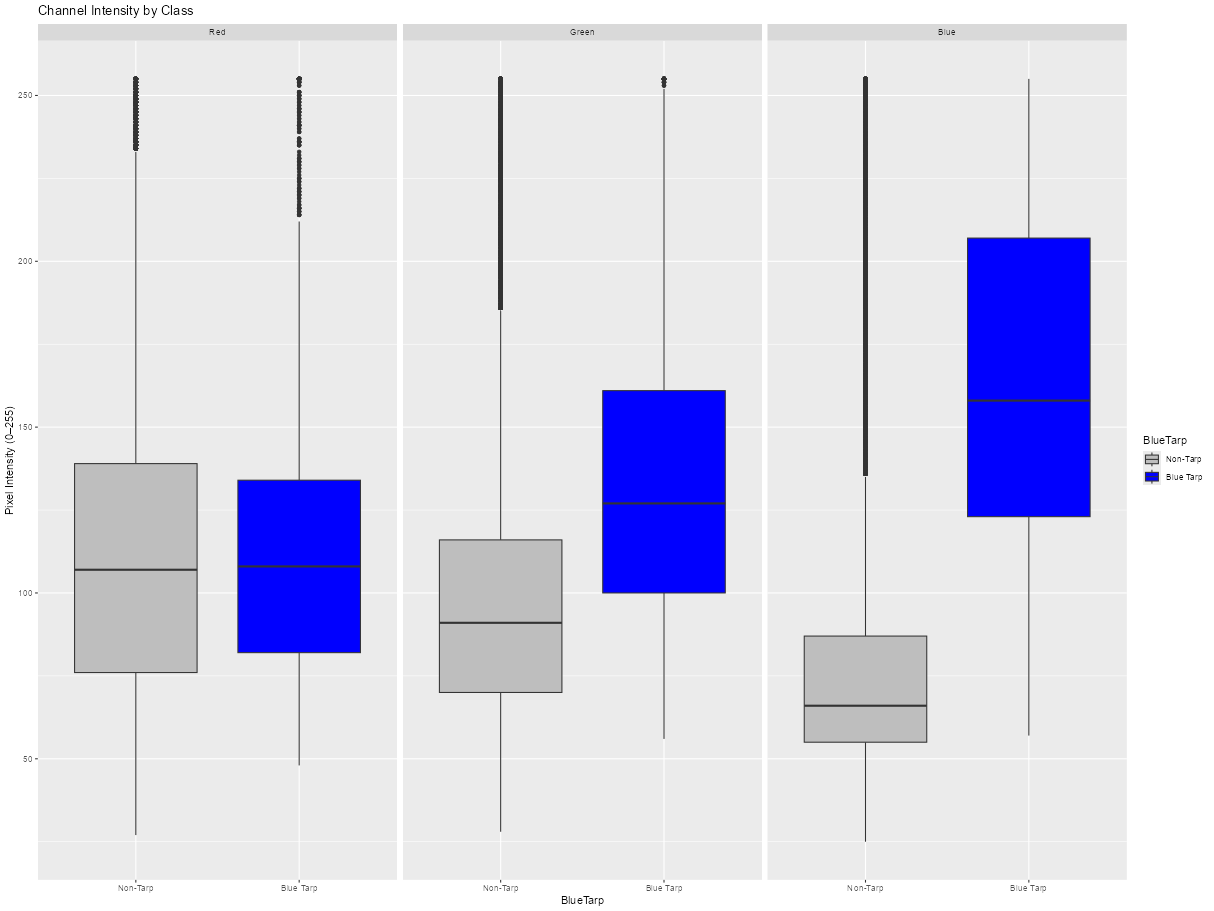

In [28]:
df <- holdout |>
  pivot_longer(cols = c(Red, Green, Blue),
               names_to  = "Channel",
               values_to = "Intensity") |>
  mutate(Channel = factor(Channel, levels = c("Red", "Green", "Blue")))
glimpse(df)

ggplot(df, aes(x = BlueTarp, y = Intensity, fill = BlueTarp)) +
  geom_boxplot() +
  facet_wrap(~Channel, ncol = 3) +
  scale_fill_manual(values = c("Non-Tarp" = "grey", "Blue Tarp" = "blue")) +
  labs(title = "Channel Intensity by Class",
       y = "Pixel Intensity (0–255)")

# LDA

In [ ]:
library(recipes)
library(discrim)

